In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import os

In [3]:
base_path = "/content/drive/MyDrive/DATASET_CV"


X = np.load(os.path.join(base_path, 'pre_X.npy'))
y = np.load(os.path.join(base_path, 'pre_y.npy'))
group = np.load(os.path.join(base_path , 'pre_groups.npy'))

print(f"Data Pre Berhasil di-load!")
print(f"Shape X: {X.shape}") # Ekspektasi: (N, 30, 2)
print(f"Shape group: {group.shape}")
print(f"Shape y: {y.shape}") # Ekspektasi: (N,)
print(np.unique(group))

Data Pre Berhasil di-load!
Shape X: (64386, 30, 2)
Shape group: (64386,)
Shape y: (64386,)
['001' '002' '005' '006']


In [4]:
ori_X = np.load(os.path.join(base_path, 'X_original.npy'))
ori_y = np.load(os.path.join(base_path, 'y_original.npy'))
ori_group = np.load(os.path.join(base_path , 'ori_groups.npy'))
print(f"Data Original Berhasil di-load!")
print(f"Shape X: {ori_X.shape}") # Ekspektasi: (N, 30, 2)
print(f"Shape group: {ori_group.shape}")
print(f"Shape y: {ori_y.shape}") # Ekspektasi: (N,)
print(np.unique(ori_group))


Data Original Berhasil di-load!
Shape X: (64522, 30, 2)
Shape group: (64522,)
Shape y: (64522,)
['001' '002' '005' '006']


In [5]:
dark_X = np.load(os.path.join(base_path, 'dark_X.npy'))
dark_y = np.load(os.path.join(base_path, 'dark_y.npy'))
dark_group = np.load(os.path.join(base_path , 'dark_groups.npy'))
print(f"Data Dark Berhasil di-load!")
print(f"Shape X: {dark_X.shape}") # Ekspektasi: (N, 30, 2)
print(f"Shape group: {dark_group.shape}")
print(f"Shape y: {dark_y.shape}") # Ekspektasi: (N,)
print(np.unique(dark_group))

Data Dark Berhasil di-load!
Shape X: (64313, 30, 2)
Shape group: (64313,)
Shape y: (64313,)
['001' '002' '005' '006']


In [6]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X,y, groups=group))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [7]:
print("Train groups:", set(group[train_idx]))
print("Test groups :", set(group[test_idx]))

Train groups: {np.str_('006'), np.str_('001'), np.str_('005')}
Test groups : {np.str_('002')}


In [8]:
ori_train_idx, ori_test_idx = next(gss.split(ori_X,ori_y, groups=ori_group))
dark_train_idx, dark_test_idk = next(gss.split(dark_X , dark_y, groups=dark_group))

X_train_ori, X_test_ori = ori_X[ori_train_idx], ori_X[ori_test_idx]
y_train_ori, y_test_ori = ori_y[ori_train_idx], ori_y[ori_test_idx]

X_train_dark, X_test_dark = dark_X[dark_train_idx], dark_X[dark_test_idk]
y_train_dark, y_test_dark = dark_y[dark_train_idx], dark_y[dark_test_idk]

print("ORIGINAL")
print("Train groups:", set(ori_group[ori_train_idx]))
print("Test groups :", set(ori_group[ori_test_idx]))
print("======================================")
print("DARK")
print("Train groups:", set(dark_group[dark_train_idx]))
print("Test groups :", set(dark_group[dark_test_idk]))


ORIGINAL
Train groups: {np.str_('006'), np.str_('001'), np.str_('005')}
Test groups : {np.str_('002')}
DARK
Train groups: {np.str_('006'), np.str_('001'), np.str_('005')}
Test groups : {np.str_('002')}


In [9]:
from sklearn.model_selection import train_test_split

X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)


In [10]:
X_train2_ori, X_val_ori, y_train2_ori, y_val_ori = train_test_split(
    X_train_ori, y_train_ori,
    test_size=0.2,
    random_state=42,
    stratify=y_train_ori
)

X_train2_dark, X_val_dark, y_train2_dark, y_val_dark = train_test_split(
    X_train_dark, y_train_dark,
    test_size=0.2,
    random_state=42,
    stratify=y_train_dark
)

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [12]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30,2)),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


model_ori = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30, 2)),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])
model_ori.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


model_dark = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30, 2)),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])
model_dark.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,801 (206.25 KB)

 Trainable params: 52,545 (205.25 KB)

 Non-trainable params: 256 (1.00 KB)

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [14]:

history = model.fit(
    X_train2, y_train2,
    epochs=50, # Kasih angka gede aja, nanti di-stop EarlyStopping
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 52s 41ms/step - accuracy: 0.6716 - loss: 0.5726 - val_accuracy: 0.6127 - val_loss: 0.7720
Epoch 2/50
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 45s 38ms/step - accuracy: 0.6896 - loss: 0.5409 - val_accuracy: 0.6662 - val_loss: 0.7276
Epoch 3/50
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 47s 41ms/step - accuracy: 0.7007 - loss: 0.5261 - val_accuracy: 0.7063 - val_loss: 0.5352
Epoch 4/50
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 79s 38ms/step - accuracy: 0.7177 - loss: 0.5043 - val_accuracy: 0.6111 - val_loss: 0.6766
Epoch 5/50
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step - accuracy: 0.7378 - loss: 0.4830 - val_accuracy: 0.7327 - val_loss: 0.4867
Epoch 6/50
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.7518 - loss: 0.4713 - val_accuracy: 0.7335 - val_loss: 0.4934
Epoch 7/50
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.7596 - loss: 0.4618 - val_accuracy: 0.7448 - val_loss: 0.5211
Epoch 8/50
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step - accuracy: 0.7694 -

In [15]:
history_ori = model_ori.fit(
    X_train2_ori, y_train2_ori,
    epochs=50, # Kasih angka gede aja, nanti di-stop EarlyStopping
    batch_size=32,
    validation_data=(X_val_ori, y_val_ori),
    callbacks=[early_stop]
)

Epoch 1/50
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 51s 39ms/step - accuracy: 0.6569 - loss: 0.6188 - val_accuracy: 0.6720 - val_loss: 0.5910
Epoch 2/50
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.6737 - loss: 0.5866 - val_accuracy: 0.6360 - val_loss: 0.6411
Epoch 3/50
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 45s 39ms/step - accuracy: 0.6883 - loss: 0.5607 - val_accuracy: 0.6390 - val_loss: 0.6633
Epoch 4/50
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 45s 38ms/step - accuracy: 0.7115 - loss: 0.5213 - val_accuracy: 0.7287 - val_loss: 0.4997
Epoch 5/50
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 46s 39ms/step - accuracy: 0.7258 - loss: 0.4976 - val_accuracy: 0.6764 - val_loss: 0.9091


In [16]:
history_dark = model_dark.fit(
    X_train2_dark, y_train2_dark,
    epochs=50, # Kasih angka gede aja, nanti di-stop EarlyStopping
    batch_size=32,
    validation_data=(X_val_dark, y_val_dark),
    callbacks=[early_stop]
)

Epoch 1/50
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 50s 39ms/step - accuracy: 0.6543 - loss: 0.6094 - val_accuracy: 0.6593 - val_loss: 0.5796
Epoch 2/50
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 45s 38ms/step - accuracy: 0.6797 - loss: 0.5731 - val_accuracy: 0.6900 - val_loss: 0.5539
Epoch 3/50
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 45s 39ms/step - accuracy: 0.6902 - loss: 0.5600 - val_accuracy: 0.6948 - val_loss: 0.5446
Epoch 4/50
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 45s 39ms/step - accuracy: 0.7010 - loss: 0.5449 - val_accuracy: 0.7072 - val_loss: 0.5276
Epoch 5/50
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 51s 44ms/step - accuracy: 0.7179 - loss: 0.5225 - val_accuracy: 0.7318 - val_loss: 0.5235


In [17]:
# Ambil index epoch dengan val_loss terendah (terbaik)
best_epoch = np.argmin(history.history['val_loss'])
best_epoch_ori = np.argmin(history_ori.history['val_loss'])
best_epoch_dark = np.argmin(history_dark.history['val_loss'])

print("=== Performance Metrics (Best Epoch PRE) ===")
print(f"Best Epoch: {best_epoch + 1}")
print(f"Train Accuracy: {history.history['accuracy'][best_epoch]:.4f}")
print(f"Val Accuracy:   {history.history['val_accuracy'][best_epoch]:.4f}")
print(f"Val Loss:       {history.history['val_loss'][best_epoch]:.4f}")

print("===================================================")
print("=== Performance Metrics (Best Epoch Original) ===")
print(f"Best Epoch: {best_epoch_ori + 1}")
print(f"Train Accuracy: {history_ori.history['accuracy'][best_epoch_ori]:.4f}")
print(f"Val Accuracy:   {history_ori.history['val_accuracy'][best_epoch_ori]:.4f}")
print(f"Val Loss:       {history_ori.history['val_loss'][best_epoch_ori]:.4f}")


print("===================================================")
print("=== Performance Metrics (Best Epoch Dark) ===")
print(f"Best Epoch: {best_epoch_dark + 1}")
print(f"Train Accuracy: {history_dark.history['accuracy'][best_epoch_dark]:.4f}")
print(f"Val Accuracy:   {history_dark.history['val_accuracy'][best_epoch_dark]:.4f}")
print(f"Val Loss:       {history_dark.history['val_loss'][best_epoch_dark]:.4f}")

=== Performance Metrics (Best Epoch PRE) ===
Best Epoch: 46
Train Accuracy: 0.9567
Val Accuracy:   0.9794
Val Loss:       0.0596
=== Performance Metrics (Best Epoch Original) ===
Best Epoch: 4
Train Accuracy: 0.7115
Val Accuracy:   0.7287
Val Loss:       0.4997
=== Performance Metrics (Best Epoch Dark) ===
Best Epoch: 5
Train Accuracy: 0.7179
Val Accuracy:   0.7318
Val Loss:       0.5235


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

In [19]:
def get_metrics(model, X_test, y_test):
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

In [20]:
metrics_pre = get_metrics(model, X_test, y_test)
metrics_ori = get_metrics(model_ori, X_test_ori, y_test_ori)
metrics_dark = get_metrics(model_dark, X_test_dark, y_test_dark)

561/561 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step
563/563 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step
560/560 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step


In [21]:
df_compare = pd.DataFrame({
    "Model Pre": metrics_pre,
    "Model Original": metrics_ori,
    "Model Dark": metrics_dark
}).T

print("\n=== Perbandingan Performa Model")
display(df_compare.round(4))


=== Perbandingan Performa Model


,Accuracy,Precision,Recall,F1-Score
Model Pre,0.6249,0.7361,0.5515,0.6306
Model Original,0.6181,0.6738,0.6595,0.6666
Model Dark,0.5722,0.6235,0.6675,0.6447


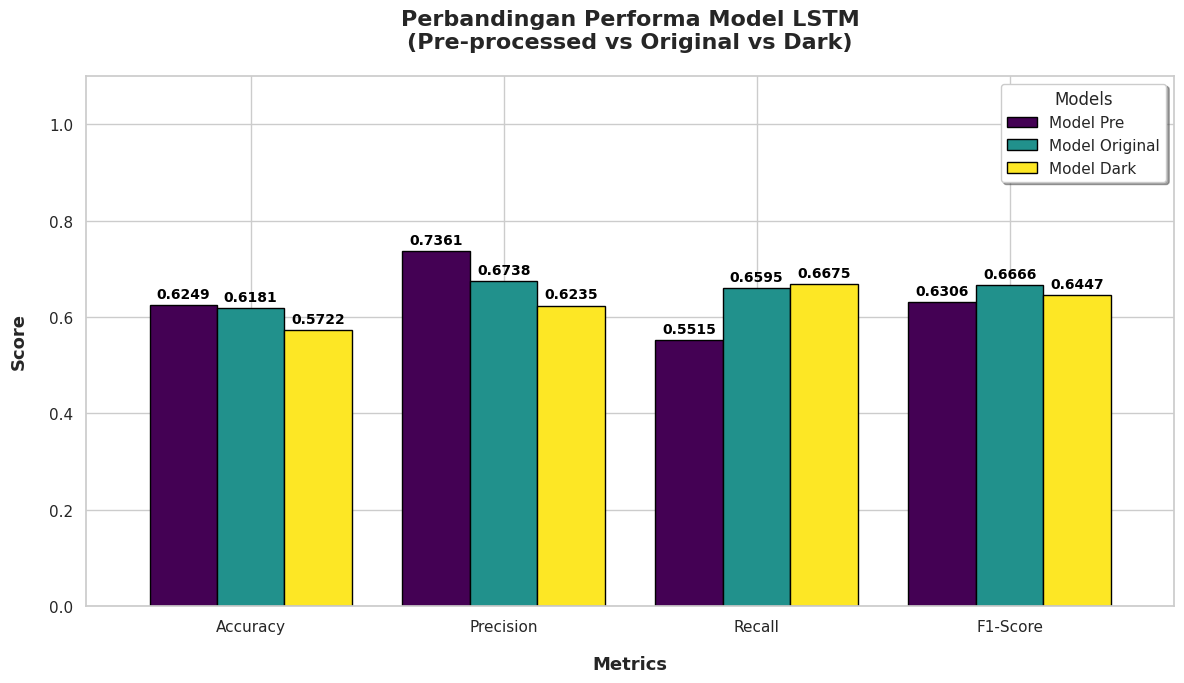

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Atur tema visualisasi agar rapi dan modern
sns.set_theme(style="whitegrid")

# 2. Transpose df_compare supaya Metrik jadi Sumbu X, dan Model jadi Warna Bar
# Ini bikin perbandingan per metrik jadi jauh lebih keliatan jelas
ax = df_compare.T.plot(kind='bar', figsize=(12, 7), colormap='viridis', edgecolor='black', width=0.8)

# 3. Kustomisasi Judul dan Label
plt.title('Perbandingan Performa Model LSTM\n(Pre-processed vs Original vs Dark)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Metrics', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('Score', fontsize=13, fontweight='bold', labelpad=15)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, 1.1)  # Diberi space sampai 1.1 supaya text angka di atas bar tidak terpotong

# 4. Tambahkan angka presisi di atas setiap bar otomatis
for p in ax.patches:
    if p.get_height() > 0: # Pastikan bar tidak kosong
        ax.annotate(f"{p.get_height():.4f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='black')

# 5. Atur posisi dan judul Legend (Keterangan Model)
plt.legend(title='Models', fontsize=11, title_fontsize='12', loc='upper right', frameon=True, shadow=True)

# 6. Tampilkan Plot
plt.tight_layout()
plt.show()

In [23]:
model.save('/content/drive/MyDrive/DATASET_CV/model/model_preDark.keras')
model_ori.save('/content/drive/MyDrive/DATASET_CV/model/model_ori.keras')
model_dark.save('/content/drive/MyDrive/DATASET_CV/model/model_dark.keras')

Load Model Pre-Dark


In [24]:
from tensorflow.keras.models import load_model


In [25]:
model = load_model('/content/drive/MyDrive/DATASET_CV/model/model_preDark.keras')

In [26]:
# Predict
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Hitung Metrik Satuan
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

561/561 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step


In [27]:
print("\n=== Final Preprocessing - Dark Test Evaluation ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Not Drowsy', 'Drowsy']))


=== Final Preprocessing - Dark Test Evaluation ===
Accuracy  : 0.6249
Precision : 0.7361
Recall    : 0.5515
F1 Score  : 0.6306

=== Classification Report ===
              precision    recall  f1-score   support

  Not Drowsy       0.54      0.73      0.62      7520
      Drowsy       0.74      0.55      0.63     10407

    accuracy                           0.62     17927
   macro avg       0.64      0.64      0.62     17927
weighted avg       0.65      0.62      0.63     17927

